In [2]:
import numpy as np
import pandas as pd
df = pd.read_csv('taxi_trip_pricing.csv')
df

,Trip_Distance_km,Time_of_Day,Day_of_Week,Passenger_Count,Traffic_Conditions,Weather,Base_Fare,Per_Km_Rate,Per_Minute_Rate,Trip_Duration_Minutes,Trip_Price
0,19.35,Morning,Weekday,3.0,Low,Clear,3.56,0.80,0.32,53.82,36.2624
1,47.59,Afternoon,Weekday,1.0,High,Clear,NaN,0.62,0.43,40.57,NaN
2,36.87,Evening,Weekend,1.0,High,Clear,2.70,1.21,0.15,37.27,52.9032
3,30.33,Evening,Weekday,4.0,Low,NaN,3.48,0.51,0.15,116.81,36.4698
4,NaN,Evening,Weekday,3.0,High,Clear,2.93,0.63,0.32,22.64,15.6180
...,...,...,...,...,...,...,...,...,...,...,...
995,5.49,Afternoon,Weekend,4.0,Medium,Clear,2.39,0.62,0.49,58.39,34.4049
996,45.95,Night,Weekday,4.0,Medium,Clear,3.12,0.61,NaN,61.96,62.1295
997,7.70,Morning,Weekday,3.0,Low,Rain,2.08,1.78,NaN,54.18,33.1236
998,47.56,Morning,Weekday,1.0,Low,Clear,2.67,0.82,0.17,114.94,61.2090


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Trip_Distance_km       950 non-null    float64
 1   Time_of_Day            950 non-null    object 
 2   Day_of_Week            950 non-null    object 
 3   Passenger_Count        950 non-null    float64
 4   Traffic_Conditions     950 non-null    object 
 5   Weather                950 non-null    object 
 6   Base_Fare              950 non-null    float64
 7   Per_Km_Rate            950 non-null    float64
 8   Per_Minute_Rate        950 non-null    float64
 9   Trip_Duration_Minutes  950 non-null    float64
 10  Trip_Price             951 non-null    float64
dtypes: float64(7), object(4)
memory usage: 86.1+ KB


In [4]:
df.describe()

,Trip_Distance_km,Passenger_Count,Base_Fare,Per_Km_Rate,Per_Minute_Rate,Trip_Duration_Minutes,Trip_Price
count,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,951.000000
mean,27.070547,2.476842,3.502989,1.233316,0.292916,62.118116,56.874773
std,19.905300,1.102249,0.870162,0.429816,0.115592,32.154406,40.469791
min,1.230000,1.000000,2.010000,0.500000,0.100000,5.010000,6.126900
25%,12.632500,1.250000,2.730000,0.860000,0.190000,35.882500,33.742650
50%,25.830000,2.000000,3.520000,1.220000,0.290000,61.860000,50.074500
75%,38.405000,3.000000,4.260000,1.610000,0.390000,89.055000,69.099350
max,146.067047,4.000000,5.000000,2.000000,0.500000,119.840000,332.043689


In [5]:
df.isnull().sum()

Trip_Distance_km         50
Time_of_Day              50
Day_of_Week              50
Passenger_Count          50
Traffic_Conditions       50
Weather                  50
Base_Fare                50
Per_Km_Rate              50
Per_Minute_Rate          50
Trip_Duration_Minutes    50
Trip_Price               49
dtype: int64

In [6]:
df['Time_of_Day'].unique()

array(['Morning', 'Afternoon', 'Evening', 'Night', nan], dtype=object)

In [7]:
df['Day_of_Week'].unique()

array(['Weekday', 'Weekend', nan], dtype=object)

In [8]:
df['Traffic_Conditions'].unique()

array(['Low', 'High', 'Medium', nan], dtype=object)

In [9]:
df['Weather'].unique()

array(['Clear', nan, 'Rain', 'Snow'], dtype=object)

In [10]:
df = df.dropna(subset=['Trip_Price'])

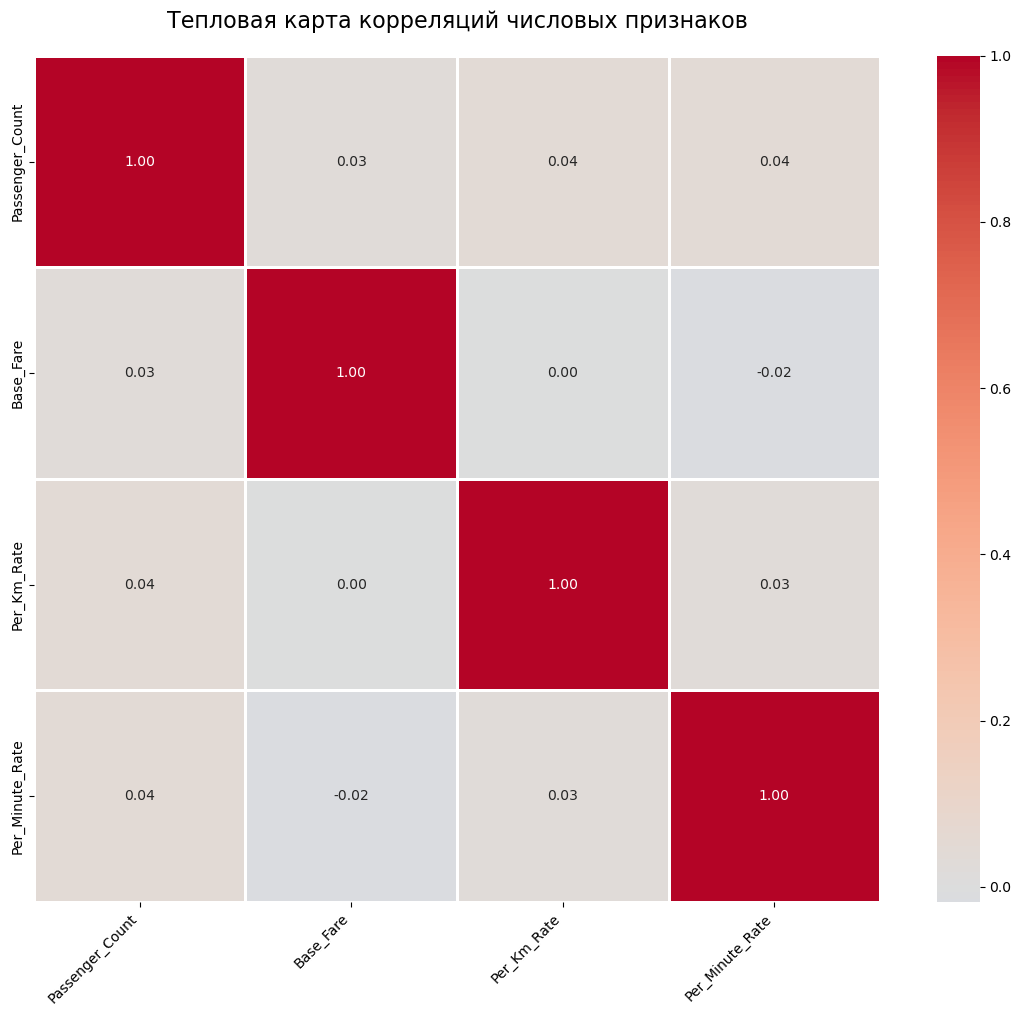

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns
numeric_cols = ['Trip_Distance', 'Passenger_Count', 'Base_Fare', 
                'Per_Km_Rate', 'Per_Minute_Rate', 'Trip_Duration', 
                'Minutes', 'Trip', 'Trip_Cost'
               ]
available_numeric = [col for col in numeric_cols if col in df.columns]
correlation_matrix = df[available_numeric].corr()
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', 
            center=0, fmt='.2f', linewidths=1, square=True)
plt.title('Тепловая карта корреляций числовых признаков', fontsize=16, pad=20)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


In [23]:
df_clean = df.dropna(subset=['Traffic_Conditions']).copy()

In [33]:

print(f"NaN в X_train_scaled: {np.isnan(X_train_scaled).sum()}")
print(f"NaN в X_test_scaled: {np.isnan(X_test_scaled).sum()}")
print(f"NaN в y_train: {np.isnan(y_train).sum()}")


if np.isnan(X_train_scaled).sum() > 0 or np.isnan(X_test_scaled).sum() > 0:
    print("Обнаружены пропущенные значения.")
    

from sklearn.impute import SimpleImputer
    
imputer = SimpleImputer(strategy='median')

NaN в X_train_scaled: 122
NaN в X_test_scaled: 53
NaN в y_train: 0
Обнаружены пропущенные значения.


In [34]:
features = [
    'Trip_Distance', 
    'Time_of_Day',      
    'Day_of_Week',      
    'Passenger_Count',
    'Weather',          
    'Base_Fare',
    'Per_Km_Rate',
    'Per_Minute_Rate',
    'Trip_Duration',
    'Minutes',
    'Trip'
]

available_features = [f for f in features if f in df_clean.columns]
print(f"Используем признаки: {available_features}")

numeric_features = df_clean[available_features].select_dtypes(include=[np.number]).columns.tolist()
categorical_features = df_clean[available_features].select_dtypes(include=['object']).columns.tolist()

print(f"Числовые признаки ({len(numeric_features)}): {numeric_features}")
print(f"Категориальные признаки ({len(categorical_features)}): {categorical_features}")

X = df_clean[available_features].copy()
y = df_clean['Traffic_Binary'].copy()

label_encoders = {}
for col in categorical_features:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
    label_encoders[col] = le
    print(f"Закодирован {col}: {dict(zip(le.classes_, le.transform(le.classes_)))}")

print(f"Размер X: {X.shape}")
print(f"Размер y: {y.shape}")

Используем признаки: ['Time_of_Day', 'Day_of_Week', 'Passenger_Count', 'Weather', 'Base_Fare', 'Per_Km_Rate', 'Per_Minute_Rate']
Числовые признаки (4): ['Passenger_Count', 'Base_Fare', 'Per_Km_Rate', 'Per_Minute_Rate']
Категориальные признаки (3): ['Time_of_Day', 'Day_of_Week', 'Weather']
Закодирован Time_of_Day: {'Afternoon': np.int64(0), 'Evening': np.int64(1), 'Morning': np.int64(2), 'Night': np.int64(3), nan: np.int64(4)}
Закодирован Day_of_Week: {'Weekday': np.int64(0), 'Weekend': np.int64(1), nan: np.int64(2)}
Закодирован Weather: {'Clear': np.int64(0), 'Rain': np.int64(1), 'Snow': np.int64(2), nan: np.int64(3)}
Размер X: (901, 7)
Размер y: (901,)


In [35]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
df_clean['Traffic_Binary'] = (df_clean['Traffic_Conditions'] == 'High').astype(int)
y = df_clean['Traffic_Binary']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.3, 
    random_state=42, 
    stratify=y  
)

print(f"Обучающая выборка: {X_train.shape}")
print(f"Тестовая выборка: {X_test.shape}")

print(f"Распределение классов в обучающей выборке:")
print(f"High Traffic (1): {y_train.sum()} ({y_train.mean()*100:.1f}%)")
print(f"Not High (0): {len(y_train) - y_train.sum()} ({(1-y_train.mean())*100:.1f}%)")

X_train_encoded = X_train.copy()
X_test_encoded = X_test.copy()


label_encoders = {}
for col in X_train_encoded.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    X_train_encoded[col] = le.fit_transform(X_train_encoded[col])
    X_test_encoded[col] = le.transform(X_test_encoded[col])
    label_encoders[col] = le

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_encoded)  
X_test_scaled = scaler.transform(X_test_encoded)

X_train_scaled = imputer.fit_transform(X_train_scaled)
X_test_scaled = imputer.transform(X_test_scaled)


log_reg.fit(X_train_scaled, y_train)

Обучающая выборка: (630, 7)
Тестовая выборка: (271, 7)
Распределение классов в обучающей выборке:
High Traffic (1): 120 (19.0%)
Not High (0): 510 (81.0%)


LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

In [36]:
from sklearn.linear_model import LogisticRegression
log_reg = LogisticRegression(
    random_state=42,
    max_iter=1000,          
    class_weight='balanced', 
    C=1.0,                   
    penalty='l2'            
)

log_reg.fit(X_train_scaled, y_train)


print(f"Количество итераций: {log_reg.n_iter_[0]}")
print(f"Коэффициенты обучены: {log_reg.coef_.shape}")


for i, (feature, coef) in enumerate(zip(available_features, log_reg.coef_[0])):
    if i < 5:  
        print(f"  {feature}: {coef:.4f}")
print("...")


print(f"Свободный член (intercept): {log_reg.intercept_[0]:.4f}")

Количество итераций: 3
Коэффициенты обучены: (1, 7)
  Time_of_Day: -0.0927
  Day_of_Week: -0.0854
  Passenger_Count: -0.0052
  Weather: -0.0598
  Base_Fare: 0.1708
...
Свободный член (intercept): -0.0262


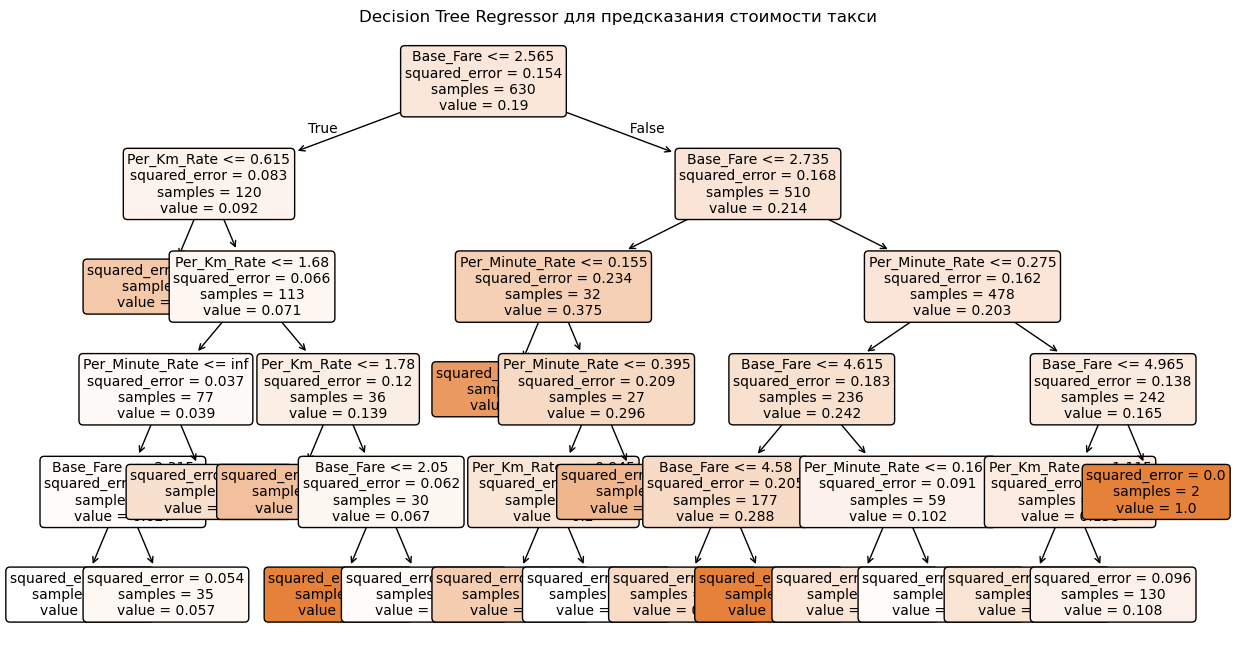

In [37]:
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
tree = DecisionTreeRegressor(
    max_depth=5,           # Ограничиваем глубину
    min_samples_split=10,  # Минимум 10 примеров для разделения
    random_state=42
)

tree.fit(X_train, y_train)


y_pred = tree.predict(X_test)

plt.figure(figsize=(15, 8))
plot_tree(tree, 
          feature_names=X.columns,
          filled=True,
          rounded=True,
          fontsize=10)
plt.title("Decision Tree Regressor для предсказания стоимости такси")
plt.show()

In [38]:
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

model = RandomForestRegressor()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

cv_scores = cross_val_score(model, X_train, y_train, cv=10, scoring='r2')
print(f"Cross-validation scores: {cv_scores}")
print(f"Average CV score: {cv_scores.mean():.3f}")
print(f"MSE: {mean_squared_error(y_test, y_pred):.2f}")
print(f"MAE: {mean_absolute_error(y_test, y_pred):.2f}")
print(f"R² score: {r2_score(y_test, y_pred) * 100:.2f}%")

Cross-validation scores: [ 0.03748971 -0.12130087 -0.13861176 -0.56413158 -0.2141675  -0.03006938
 -0.07304453 -0.06863235 -0.1472     -0.0831625 ]
Average CV score: -0.140
MSE: 0.17
MAE: 0.32
R² score: -7.44%


In [39]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae:.2f}")
print(f"MSE: {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²: {r2:.4f}")

MAE: 0.32
MSE: 0.17
RMSE: 0.41
R²: -0.0744


In [42]:
catboost_reg = CatBoostRegressor(
    iterations=500,           # Количество деревьев
    learning_rate=0.05,       # Скорость обучения
    depth=6,                  # Глубина деревьев
    loss_function='RMSE',     # Функция потерь
    random_seed=42,
    verbose=100,              # Выводить логи каждые 100 итераций
    cat_features=['Time_of_Day', 'Day_of_Week']  # Указываем категориальные признаки
)


catboost_reg.fit(X, y)


y_pred = catboost_reg.predict(X)
mae = mean_absolute_error(y, y_pred)
mse = mean_squared_error(y, y_pred)


print(f"MAE: {mae:.2f}")
print(f"MSE: {mse:.2f}")
print(f"RMSE: {np.sqrt(mse):.2f}")
print(f"R² Score: {catboost_reg.score(X, y):.4f}")

NameError: name 'CatBoostRegressor' is not defined

In [43]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
model = keras.Sequential([
    layers.Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    layers.Dense(32, activation='relu'),
    layers.Dense(16, activation='relu'),
    layers.Dense(1)  
])


model.compile(
    optimizer='adam',
    loss='mse',  
    metrics=['mae', 'mse']  
)


history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=50,
    batch_size=32,
    verbose=1
)


test_loss, test_mae, test_mse = model.evaluate(X_test, y_test, verbose=0)
print(f"\nРезультаты на тесте:")
print(f"MAE: {test_mae:.2f}")
print(f"MSE: {test_mse:.2f}")
print(f"RMSE: {np.sqrt(test_mse):.2f}")


y_pred = model.predict(X_test).flatten()

Epoch 1/50


C:\Users\user\Downloads\UDL Downloads\Lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - loss: 0.1755 - mae: 0.2185 - mse: 0.1755 - val_loss: 0.1649 - val_mae: 0.2491 - val_mse: 0.1649
Epoch 2/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.1572 - mae: 0.2742 - mse: 0.1572 - val_loss: 0.1553 - val_mae: 0.3000 - val_mse: 0.1553
Epoch 3/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.1544 - mae: 0.3122 - mse: 0.1544 - val_loss: 0.1554 - val_mae: 0.3208 - val_mse: 0.1554
Epoch 4/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.1543 - mae: 0.3136 - mse: 0.1543 - val_loss: 0.1551 - val_mae: 0.3111 - val_mse: 0.1551
Epoch 5/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.1544 - mae: 0.3070 - mse: 0.1544 - val_loss: 0.1551 - val_mae: 0.3062 - val_mse: 0.1551
Epoch 6/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.1544 - mae: 0.3090 - mse: 0.1544 - val_loss: 0.1551 - val_mae: 0.3101 - val_mse: 0.1551
Epoch 7/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.1544 - mae: 0.3103 - mse: 0.1544 - val_loss: 0.1551 - val_mae:

In [44]:
from sklearn.model_selection import cross_val_score, KFold
kf = KFold(n_splits=3, shuffle=True, random_state=42)

print(f"KFold с {kf.get_n_splits(X)} фолдами")
print(f"Всего данных: {len(X)}")
print()

for i, (train_idx, test_idx) in enumerate(kf.split(X)):
    print(f"Фолд {i}:")
    print(f"Train: {len(train_idx)} примеров (индексы {train_idx[:5]}...)")
    print(f"Test:  {len(test_idx)} примеров (индексы {test_idx[:5]}...)")
    print()

KFold с 3 фолдами
Всего данных: 901

Фолд 0:
Train: 600 примеров (индексы [0 1 3 4 8]...)
Test:  301 примеров (индексы [ 2  5  6  7 10]...)

Фолд 1:
Train: 601 примеров (индексы [1 2 4 5 6]...)
Test:  300 примеров (индексы [ 0  3  9 11 12]...)

Фолд 2:
Train: 601 примеров (индексы [0 2 3 5 6]...)
Test:  300 примеров (индексы [ 1  4  8 13 14]...)

